
# ModServe Supporting Validation Demo Pipeline

This notebook combines the core steps from the three ModServe notebooks into one streamlined demo:

1. load and clean the Azure multimodal inference trace,
2. reproduce the key workload-characterization plots,
3. build 5-minute control intervals,
4. apply the three supporting baseline policies,
5. run replay evaluation on validation and test,
6. visualize burst-day behavior.

This notebook is intended for **demo and presentation**. The original notebooks remain the detailed development notebooks.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


In [2]:

# Common path setup for local + Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    REPO_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/masters-project")
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent
    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")

DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
REPORTS_EVAL = REPO_ROOT / "reports" / "eval" / "modserve"
FIG_DIR = REPORTS_EVAL / "figures"
TABLE_DIR = REPORTS_EVAL / "tables"
CACHE_DIR = REPORTS_EVAL / "cache"
LOG_DIR = REPORTS_EVAL / "logs"

for p in [DATA_RAW, DATA_PROCESSED, FIG_DIR, TABLE_DIR, CACHE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RAW_TRACE_PATH = DATA_RAW / "AzureLMMInferenceTrace_multimodal.csv.gz"
CLEAN_REQUESTS_PATH = DATA_PROCESSED / "cleaned_requests.parquet"
WINDOWS_OUTPUT_PATH = DATA_PROCESSED / "modserve_5min_windows.parquet"
DAILY_SUMMARY_PATH = TABLE_DIR / "daily_summary.csv"
BASELINE_METADATA_PATH = TABLE_DIR / "modserve_baseline_metadata.csv"
VAL_SUMMARY_PATH = TABLE_DIR / "modserve_val_baseline_summary.csv"
TEST_SUMMARY_PATH = TABLE_DIR / "modserve_test_baseline_summary.csv"
BURST_SUMMARY_PATH = TABLE_DIR / "modserve_burst_day_summary.csv"

print("Repo root:", REPO_ROOT)
print("Running in Colab:", IN_COLAB)
print("Raw trace path:", RAW_TRACE_PATH)


Mounted at /content/drive
Repo root: /content/drive/MyDrive/Colab Notebooks/masters-project
Running in Colab: True
Raw trace path: /content/drive/MyDrive/Colab Notebooks/masters-project/data/raw/AzureLMMInferenceTrace_multimodal.csv.gz



## 1. Load and clean the request-level trace

We start from the raw Azure multimodal inference trace used in the ModServe supporting-validation track.


In [3]:

if not RAW_TRACE_PATH.exists():
    raise FileNotFoundError(f"Missing raw dataset: {RAW_TRACE_PATH}")

df = pd.read_csv(RAW_TRACE_PATH)
df = df[["TIMESTAMP", "NumImages", "ContextTokens", "GeneratedTokens"]].copy()

df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce", utc=True)
for col in ["NumImages", "ContextTokens", "GeneratedTokens"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["TIMESTAMP", "NumImages", "ContextTokens", "GeneratedTokens"]).copy()
df["NumImages"] = df["NumImages"].clip(lower=0)
df["ContextTokens"] = df["ContextTokens"].clip(lower=0)
df["GeneratedTokens"] = df["GeneratedTokens"].clip(lower=0)
df = df.sort_values("TIMESTAMP").reset_index(drop=True)

df["is_image_text"] = df["NumImages"] > 0
df["is_text_only"] = df["NumImages"] == 0
df["request_type"] = np.where(df["is_image_text"], "image_text", "text_only")
df["minute"] = df["TIMESTAMP"].dt.floor("min")
df["day"] = df["TIMESTAMP"].dt.floor("D")

df.to_parquet(CLEAN_REQUESTS_PATH, index=False)

print("Rows:", len(df))
print("Time range:", df["TIMESTAMP"].min(), "to", df["TIMESTAMP"].max())
df.head()


Rows: 1000000
Time range: 2024-10-15 12:00:00.269000+00:00 to 2024-10-22 11:59:59.964000+00:00


,TIMESTAMP,NumImages,ContextTokens,GeneratedTokens,is_image_text,is_text_only,request_type,minute,day
0,2024-10-15 12:00:00.269000+00:00,0,770,491,False,True,text_only,2024-10-15 12:00:00+00:00,2024-10-15 00:00:00+00:00
1,2024-10-15 12:00:05.819000+00:00,1,949,126,True,False,image_text,2024-10-15 12:00:00+00:00,2024-10-15 00:00:00+00:00
2,2024-10-15 12:00:06.513000+00:00,1,964,79,True,False,image_text,2024-10-15 12:00:00+00:00,2024-10-15 00:00:00+00:00
3,2024-10-15 12:00:07.332000+00:00,0,78,5,False,True,text_only,2024-10-15 12:00:00+00:00,2024-10-15 00:00:00+00:00
4,2024-10-15 12:00:07.566000+00:00,1,1724,28,True,False,image_text,2024-10-15 12:00:00+00:00,2024-10-15 00:00:00+00:00


In [4]:

print("Request type counts:")
print(df["request_type"].value_counts())

summary = df[["NumImages", "ContextTokens", "GeneratedTokens"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
summary


Request type counts:
request_type
text_only     500000
image_text    500000
Name: count, dtype: int64


,NumImages,ContextTokens,GeneratedTokens
count,1000000.000000,1000000.000000,1000000.000000
mean,14.332170,2910.954494,186.631667
std,81.263994,6403.092246,449.896605
min,0.000000,0.000000,0.000000
50%,0.500000,1124.000000,98.000000
90%,9.000000,5828.000000,433.000000
95%,25.000000,9755.000000,603.000000
99%,484.000000,35932.000000,1066.000000
max,9409.000000,148569.000000,16384.000000



## 2. Workload characterization

For demo, we keep the most important workload views:
- requests per minute by type,
- token/image rates over time,
- CDFs for prompt length and images per request.


In [5]:

def empirical_cdf(values):
    values = np.asarray(values)
    values = values[~np.isnan(values)]
    values = np.sort(values)
    y = np.arange(1, len(values) + 1) / len(values)
    return values, y

requests_per_min = (
    df.groupby(["minute", "request_type"]).size().unstack(fill_value=0).sort_index()
)
context_tokens_per_min = (
    df.groupby(["minute", "request_type"])["ContextTokens"].sum().unstack(fill_value=0).sort_index()
)
generated_tokens_per_min = (
    df.groupby(["minute", "request_type"])["GeneratedTokens"].sum().unstack(fill_value=0).sort_index()
)
images_per_min = df.groupby("minute")["NumImages"].sum().sort_index()

daily_summary = (
    df.groupby("day")
      .agg(
          requests=("TIMESTAMP", "size"),
          image_text_requests=("is_image_text", "sum"),
          text_only_requests=("is_text_only", "sum"),
          total_context_tokens=("ContextTokens", "sum"),
          total_generated_tokens=("GeneratedTokens", "sum"),
          total_images=("NumImages", "sum"),
      )
      .reset_index()
)
daily_summary["frac_image_text"] = daily_summary["image_text_requests"] / daily_summary["requests"]
daily_summary.to_csv(DAILY_SUMMARY_PATH, index=False)


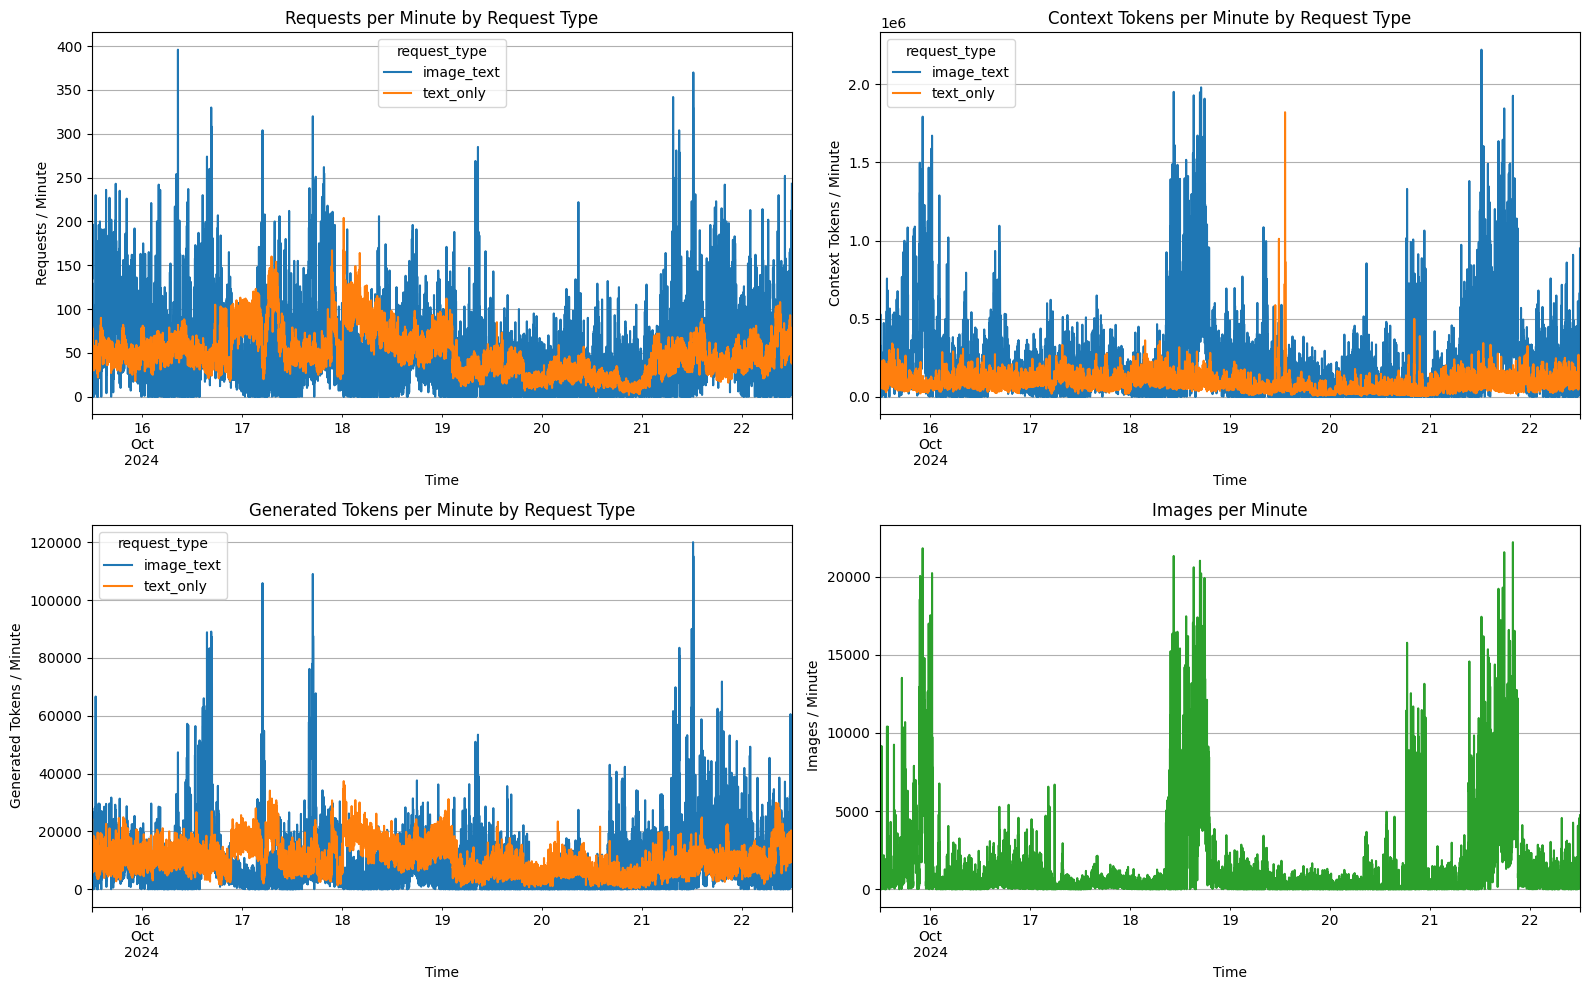

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

requests_per_min.plot(ax=axes[0, 0])
axes[0, 0].set_title("Requests per Minute by Request Type")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Requests / Minute")

context_tokens_per_min.plot(ax=axes[0, 1])
axes[0, 1].set_title("Context Tokens per Minute by Request Type")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Context Tokens / Minute")

generated_tokens_per_min.plot(ax=axes[1, 0])
axes[1, 0].set_title("Generated Tokens per Minute by Request Type")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Generated Tokens / Minute")

images_per_min.plot(ax=axes[1, 1], color="tab:green")
axes[1, 1].set_title("Images per Minute")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Images / Minute")

plt.tight_layout()
plt.savefig(FIG_DIR / "demo_workload_timeseries.png", dpi=180)
plt.show()


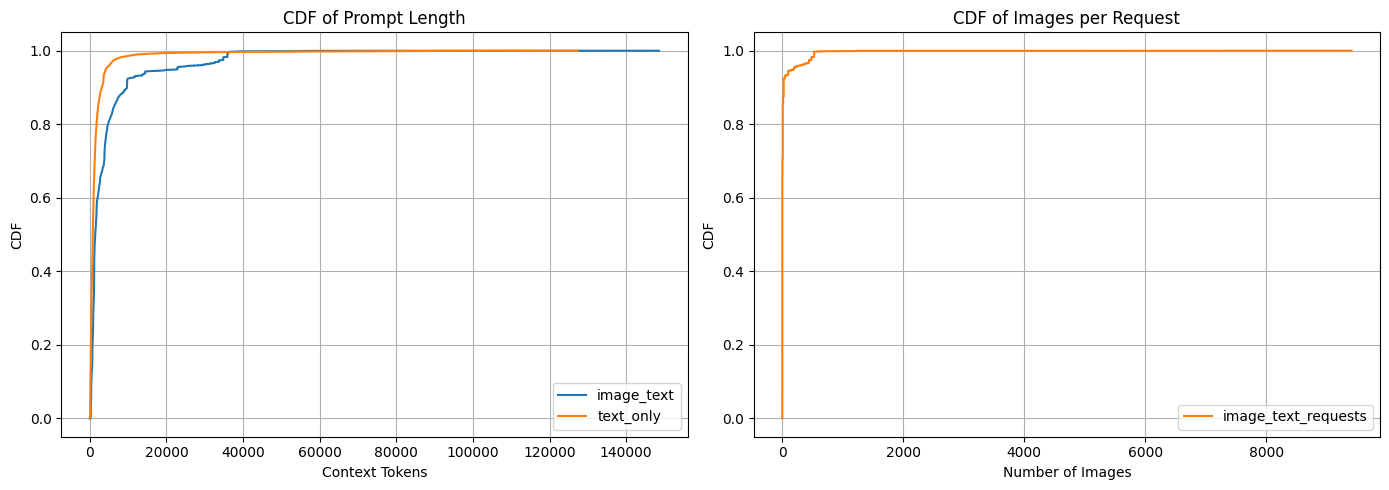

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, subset in [("image_text", df[df["is_image_text"]]), ("text_only", df[df["is_text_only"]])]:
    x, y = empirical_cdf(subset["ContextTokens"].values)
    axes[0].plot(x, y, label=label)
axes[0].set_title("CDF of Prompt Length")
axes[0].set_xlabel("Context Tokens")
axes[0].set_ylabel("CDF")
axes[0].legend()

image_requests = df[df["NumImages"] > 0].copy()
x, y = empirical_cdf(image_requests["NumImages"].values)
axes[1].plot(x, y, label="image_text_requests", color="tab:orange")
axes[1].set_title("CDF of Images per Request")
axes[1].set_xlabel("Number of Images")
axes[1].set_ylabel("CDF")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "demo_workload_cdfs.png", dpi=180)
plt.show()



## 3. Build 5-minute control intervals and baseline policies

Each row below becomes one 5-minute control interval. We then derive required image/text service units and apply the three supporting baselines:
- Fixed Monolith
- Fixed Decoupled
- Reactive Decoupled


In [9]:
df["window_start"] = df["TIMESTAMP"].dt.floor("5min")

windows = (
    df.groupby("window_start")
      .agg(
          n_requests=("TIMESTAMP", "size"),
          n_text_only=("is_text_only", "sum"),
          n_image_text=("is_image_text", "sum"),
          sum_context_tokens=("ContextTokens", "sum"),
          sum_generated_tokens=("GeneratedTokens", "sum"),
          sum_images=("NumImages", "sum"),
          mean_context_tokens=("ContextTokens", "mean"),
          mean_generated_tokens=("GeneratedTokens", "mean"),
          mean_images_per_request=("NumImages", "mean"),
      )
      .reset_index()
)

full_range = pd.date_range(
    start=windows["window_start"].min(),
    end=windows["window_start"].max(),
    freq="5min",
    tz=windows["window_start"].dt.tz,
)

windows = pd.DataFrame({"window_start": full_range}).merge(windows, on="window_start", how="left")

count_cols = [
    "n_requests", "n_text_only", "n_image_text",
    "sum_context_tokens", "sum_generated_tokens", "sum_images",
]
mean_cols = ["mean_context_tokens", "mean_generated_tokens", "mean_images_per_request"]
windows[count_cols] = windows[count_cols].fillna(0)
windows[mean_cols] = windows[mean_cols].fillna(0)

windows["requests_per_min"] = windows["n_requests"] / 5.0
windows["context_tokens_per_min"] = windows["sum_context_tokens"] / 5.0
windows["generated_tokens_per_min"] = windows["sum_generated_tokens"] / 5.0
windows["images_per_min"] = windows["sum_images"] / 5.0
windows["frac_image_text"] = np.where(
    windows["n_requests"] > 0,
    windows["n_image_text"] / windows["n_requests"],
    0.0,
)
windows["day"] = windows["window_start"].dt.floor("D")

unique_days = sorted(windows["day"].drop_duplicates())
train_days = set(unique_days[:4])
val_days = set(unique_days[4:5])

def assign_split(day):
    if day in train_days:
        return "train"
    elif day in val_days:
        return "val"
    else:
        return "test"

# Calculate required units for image and text
# These values are used to set unit capacities based on training data
# and must be calculated before splitting the data into train, val, test.
nonzero_image = windows.loc[windows["images_per_min"] > 0, "images_per_min"]
nonzero_text = windows.loc[windows["context_tokens_per_min"] > 0, "context_tokens_per_min"]
image_unit_capacity = max(1.0, float(nonzero_image.median())) if len(nonzero_image) else 1.0
text_unit_capacity = max(1.0, float(nonzero_text.median())) if len(nonzero_text) else 1.0

windows["req_image_units"] = np.ceil(windows["images_per_min"] / image_unit_capacity).astype(int)
windows["req_text_units"] = np.ceil(windows["context_tokens_per_min"] / text_unit_capacity).astype(int)
windows["req_total_units"] = windows["req_image_units"] + windows["req_text_units"]

# Now assign splits and create train_df AFTER all required columns are present in `windows`
windows["split"] = windows["day"].apply(assign_split)
train_df = windows[windows["split"] == "train"].copy()

fixed_monolith_units = int(np.ceil(train_df["req_total_units"].quantile(0.95)))
fixed_image_units = int(np.ceil(train_df["req_image_units"].quantile(0.95)))
fixed_text_units = int(np.ceil(train_df["req_text_units"].quantile(0.95)))

windows["prov_monolith_total_units"] = fixed_monolith_units
windows["prov_fixed_image_units"] = fixed_image_units
windows["prov_fixed_text_units"] = fixed_text_units
windows["prov_fixed_decoupled_total_units"] = fixed_image_units + fixed_text_units

windows["prov_reactive_image_units"] = windows["req_image_units"].shift(1).fillna(fixed_image_units).astype(int)
windows["prov_reactive_text_units"] = windows["req_text_units"].shift(1).fillna(fixed_text_units).astype(int)
windows["prov_reactive_total_units"] = windows["prov_reactive_image_units"] + windows["prov_reactive_text_units"]

windows.to_parquet(WINDOWS_OUTPUT_PATH, index=False)

metadata = pd.DataFrame({
    "key": [
        "image_unit_capacity",
        "text_unit_capacity",
        "fixed_monolith_units",
        "fixed_image_units",
        "fixed_text_units",
    ],
    "value": [
        image_unit_capacity,
        text_unit_capacity,
        fixed_monolith_units,
        fixed_image_units,
        fixed_text_units,
    ],
})
metadata.to_csv(BASELINE_METADATA_PATH, index=False)

windows[[
    "window_start", "requests_per_min", "context_tokens_per_min", "images_per_min",
    "req_image_units", "req_text_units", "req_total_units"
]].head(10)

,window_start,requests_per_min,context_tokens_per_min,images_per_min,req_image_units,req_text_units,req_total_units
0,2024-10-15 12:00:00+00:00,175.0,365573.0,460.4,1,2,3
1,2024-10-15 12:05:00+00:00,175.0,422308.2,555.0,2,2,4
2,2024-10-15 12:10:00+00:00,116.4,256675.2,404.2,1,2,3
3,2024-10-15 12:15:00+00:00,102.2,252051.0,413.6,1,2,3
4,2024-10-15 12:20:00+00:00,63.8,177930.4,1869.2,5,1,6
5,2024-10-15 12:25:00+00:00,79.4,190600.2,146.0,1,1,2
6,2024-10-15 12:30:00+00:00,80.0,212207.8,202.2,1,1,2
7,2024-10-15 12:35:00+00:00,76.2,165957.6,164.6,1,1,2
8,2024-10-15 12:40:00+00:00,113.8,272170.2,379.8,1,2,3
9,2024-10-15 12:45:00+00:00,97.4,221165.2,202.8,1,1,2



## 4. Replay evaluation

We now evaluate the three baseline policies on validation and test using the same replay metrics.


In [10]:

def summarize_monolith(df, baseline_name, provision_col):
    tmp = df.copy()
    tmp["provided_total_units"] = tmp[provision_col]
    tmp["under_units"] = (tmp["req_total_units"] - tmp["provided_total_units"]).clip(lower=0)
    tmp["over_units"] = (tmp["provided_total_units"] - tmp["req_total_units"]).clip(lower=0)
    tmp["slo_safe_window"] = tmp["under_units"] == 0
    return {
        "baseline": baseline_name,
        "n_windows": len(tmp),
        "avg_required_units": tmp["req_total_units"].mean(),
        "avg_provisioned_units": tmp["provided_total_units"].mean(),
        "peak_required_units": tmp["req_total_units"].max(),
        "peak_provisioned_units": tmp["provided_total_units"].max(),
        "slo_safe_rate": tmp["slo_safe_window"].mean(),
        "underprovision_rate": (tmp["under_units"] > 0).mean(),
        "overprovision_rate": (tmp["over_units"] > 0).mean(),
        "avg_under_units": tmp["under_units"].mean(),
        "avg_over_units": tmp["over_units"].mean(),
    }

def summarize_decoupled(df, baseline_name, image_col, text_col):
    tmp = df.copy()
    tmp["provided_image_units"] = tmp[image_col]
    tmp["provided_text_units"] = tmp[text_col]
    tmp["provided_total_units"] = tmp["provided_image_units"] + tmp["provided_text_units"]
    tmp["under_image_units"] = (tmp["req_image_units"] - tmp["provided_image_units"]).clip(lower=0)
    tmp["under_text_units"] = (tmp["req_text_units"] - tmp["provided_text_units"]).clip(lower=0)
    tmp["over_image_units"] = (tmp["provided_image_units"] - tmp["req_image_units"]).clip(lower=0)
    tmp["over_text_units"] = (tmp["provided_text_units"] - tmp["req_text_units"]).clip(lower=0)
    tmp["under_units"] = tmp["under_image_units"] + tmp["under_text_units"]
    tmp["over_units"] = tmp["over_image_units"] + tmp["over_text_units"]
    tmp["slo_safe_window"] = (tmp["under_image_units"] == 0) & (tmp["under_text_units"] == 0)
    return {
        "baseline": baseline_name,
        "n_windows": len(tmp),
        "avg_required_units": tmp["req_total_units"].mean(),
        "avg_provisioned_units": tmp["provided_total_units"].mean(),
        "avg_provisioned_image_units": tmp["provided_image_units"].mean(),
        "avg_provisioned_text_units": tmp["provided_text_units"].mean(),
        "peak_required_units": tmp["req_total_units"].max(),
        "peak_provisioned_units": tmp["provided_total_units"].max(),
        "slo_safe_rate": tmp["slo_safe_window"].mean(),
        "underprovision_rate": (tmp["under_units"] > 0).mean(),
        "overprovision_rate": (tmp["over_units"] > 0).mean(),
        "avg_under_units": tmp["under_units"].mean(),
        "avg_over_units": tmp["over_units"].mean(),
    }

val_df = windows[windows["split"] == "val"].copy()
test_df = windows[windows["split"] == "test"].copy()

val_results_df = pd.DataFrame([
    summarize_monolith(val_df, "Fixed Monolith", "prov_monolith_total_units"),
    summarize_decoupled(val_df, "Fixed Decoupled", "prov_fixed_image_units", "prov_fixed_text_units"),
    summarize_decoupled(val_df, "Reactive Decoupled", "prov_reactive_image_units", "prov_reactive_text_units"),
])

test_results_df = pd.DataFrame([
    summarize_monolith(test_df, "Fixed Monolith", "prov_monolith_total_units"),
    summarize_decoupled(test_df, "Fixed Decoupled", "prov_fixed_image_units", "prov_fixed_text_units"),
    summarize_decoupled(test_df, "Reactive Decoupled", "prov_reactive_image_units", "prov_reactive_text_units"),
])

val_results_df.to_csv(VAL_SUMMARY_PATH, index=False)
test_results_df.to_csv(TEST_SUMMARY_PATH, index=False)

test_results_df[[
    "baseline", "avg_required_units", "avg_provisioned_units", "slo_safe_rate",
    "underprovision_rate", "overprovision_rate", "avg_under_units", "avg_over_units"
]].sort_values("slo_safe_rate", ascending=False)


,baseline,avg_required_units,avg_provisioned_units,slo_safe_rate,underprovision_rate,overprovision_rate,avg_under_units,avg_over_units
0,Fixed Monolith,5.969444,22.000000,0.958333,0.041667,0.947222,0.169444,16.200000
1,Fixed Decoupled,5.969444,21.000000,0.947222,0.052778,0.937500,0.222222,15.252778
2,Reactive Decoupled,5.969444,5.961111,0.691667,0.308333,0.294444,0.920833,0.912500


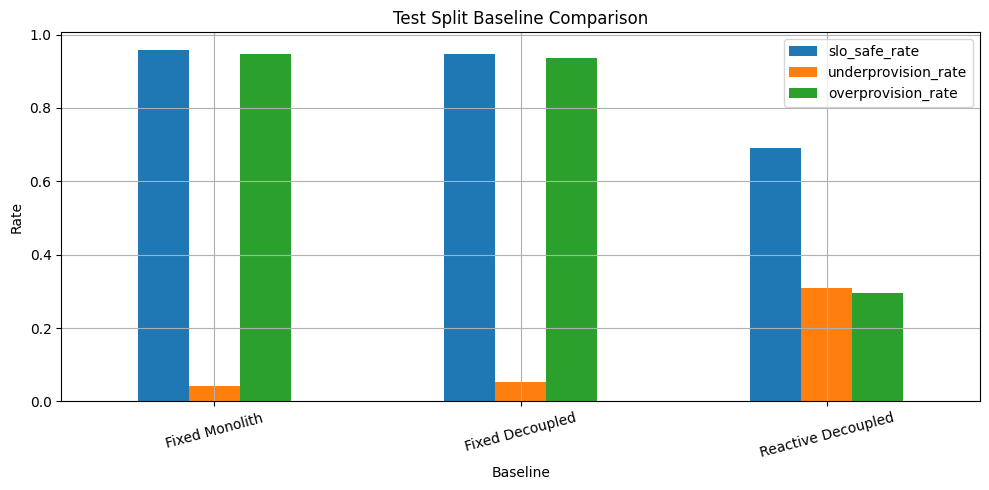

In [11]:

plot_df = test_results_df.set_index("baseline")[["slo_safe_rate", "underprovision_rate", "overprovision_rate"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Test Split Baseline Comparison")
plt.xlabel("Baseline")
plt.ylabel("Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "demo_test_baseline_rates.png", dpi=180)
plt.show()


### Reliability vs Efficiency Tradeoff

For demo, we also summarize the three ModServe baselines using a two-axis tradeoff plot similar to the Splitwise figure.

- **Reliability** is measured by **underprovision rate (%)**.
- **Efficiency** is measured by **replay utilization (%)**, defined as:

\[
\text{utilization} = \frac{\text{avg required units}}{\text{avg provisioned units}} \times 100
\]

Lower underprovision means safer provisioning, while higher utilization means better resource efficiency.


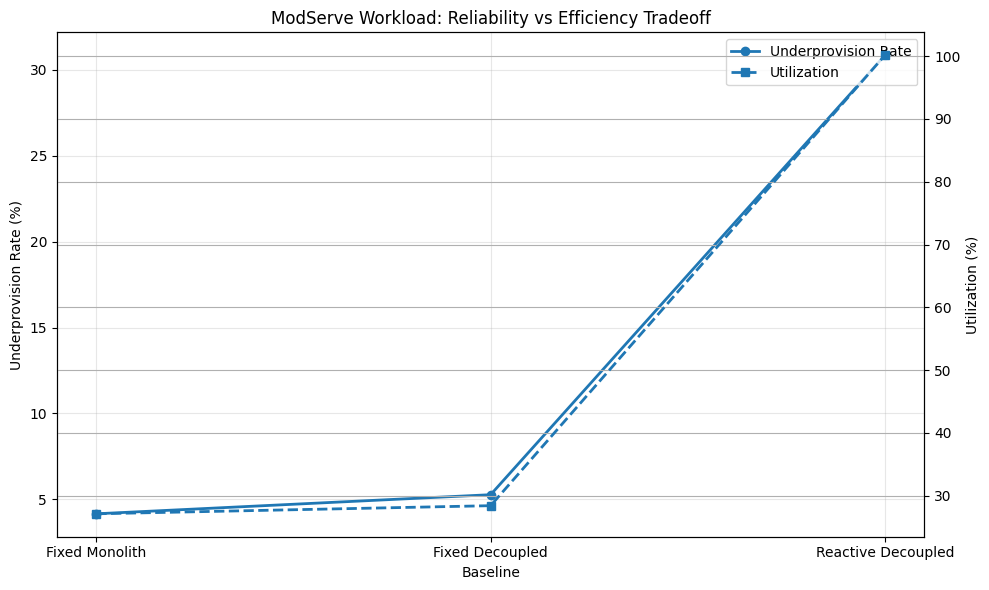

,baseline,underprovision_pct,utilization_pct,avg_required_units,avg_provisioned_units
0,Fixed Monolith,4.166667,27.133838,5.969444,22.000000
1,Fixed Decoupled,5.277778,28.425926,5.969444,21.000000
2,Reactive Decoupled,30.833333,100.139795,5.969444,5.961111


In [12]:
tradeoff_df = test_results_df.copy()
tradeoff_df["underprovision_pct"] = tradeoff_df["underprovision_rate"] * 100
tradeoff_df["utilization_pct"] = (
    tradeoff_df["avg_required_units"] / tradeoff_df["avg_provisioned_units"] * 100
)

baseline_order = ["Fixed Monolith", "Fixed Decoupled", "Reactive Decoupled"]
tradeoff_df["baseline"] = pd.Categorical(
    tradeoff_df["baseline"], categories=baseline_order, ordered=True
)
tradeoff_df = tradeoff_df.sort_values("baseline")

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    tradeoff_df["baseline"],
    tradeoff_df["underprovision_pct"],
    marker="o",
    linewidth=2,
    label="Underprovision Rate"
)
ax1.set_xlabel("Baseline")
ax1.set_ylabel("Underprovision Rate (%)")
ax1.set_title("ModServe Workload: Reliability vs Efficiency Tradeoff")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    tradeoff_df["baseline"],
    tradeoff_df["utilization_pct"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Utilization"
)
ax2.set_ylabel("Utilization (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "demo_modserve_reliability_vs_efficiency.png", dpi=180, bbox_inches="tight")
plt.show()

tradeoff_df[["baseline", "underprovision_pct", "utilization_pct", "avg_required_units", "avg_provisioned_units"]]


## 5. Burst-day analysis

We isolate the burstiest test day and compare required versus provisioned units.


In [13]:

burst_day_table = (
    test_df.groupby("day")
           .agg(
               peak_images_per_min=("images_per_min", "max"),
               total_images=("sum_images", "sum"),
               peak_requests_per_min=("requests_per_min", "max"),
           )
           .sort_values(["peak_images_per_min", "total_images"], ascending=False)
)

burst_day = burst_day_table.index[0]
burst_df = test_df[test_df["day"] == burst_day].copy()

burst_results_df = pd.DataFrame([
    summarize_monolith(burst_df, "Fixed Monolith", "prov_monolith_total_units"),
    summarize_decoupled(burst_df, "Fixed Decoupled", "prov_fixed_image_units", "prov_fixed_text_units"),
    summarize_decoupled(burst_df, "Reactive Decoupled", "prov_reactive_image_units", "prov_reactive_text_units"),
])

burst_results_df.to_csv(BURST_SUMMARY_PATH, index=False)
print("Chosen burst day:", burst_day)
burst_results_df[["baseline", "slo_safe_rate", "underprovision_rate", "overprovision_rate", "avg_provisioned_units"]]


Chosen burst day: 2024-10-21 00:00:00+00:00


,baseline,slo_safe_rate,underprovision_rate,overprovision_rate,avg_provisioned_units
0,Fixed Monolith,0.895833,0.104167,0.868056,22.000000
1,Fixed Decoupled,0.868056,0.131944,0.843750,21.000000
2,Reactive Decoupled,0.635417,0.364583,0.357639,9.659722


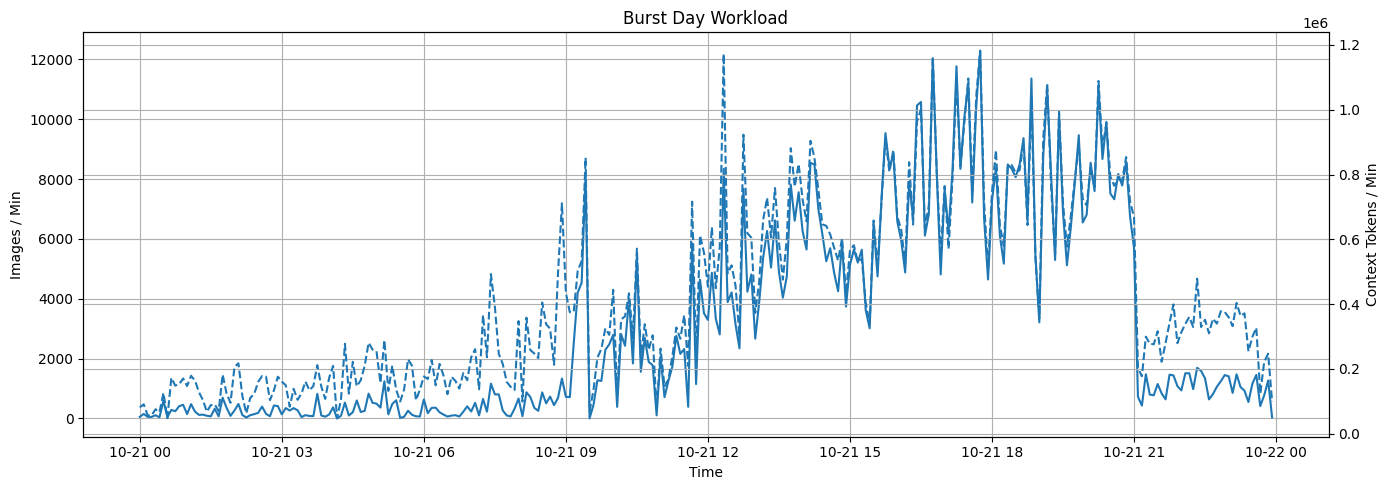

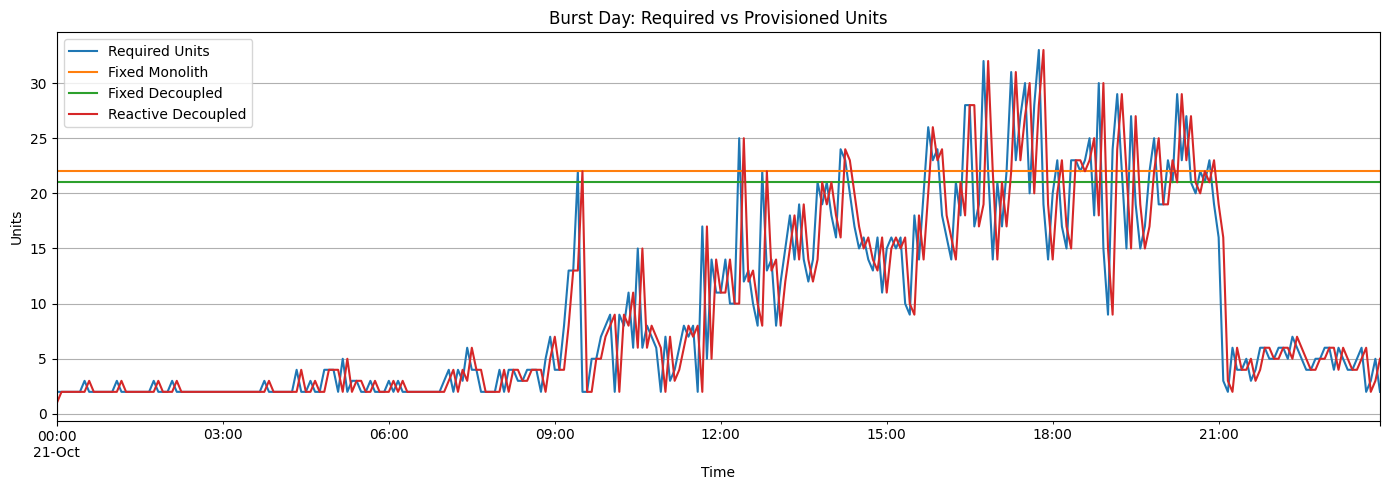

In [14]:

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(burst_df["window_start"], burst_df["images_per_min"], label="Images / Min")
ax1.set_ylabel("Images / Min")
ax1.set_xlabel("Time")
ax2 = ax1.twinx()
ax2.plot(burst_df["window_start"], burst_df["context_tokens_per_min"], linestyle="--", label="Context Tokens / Min")
ax2.set_ylabel("Context Tokens / Min")
plt.title("Burst Day Workload")
fig.tight_layout()
plt.savefig(FIG_DIR / "demo_burst_day_workload.png", dpi=180)
plt.show()

burst_plot = burst_df[[
    "window_start", "req_total_units", "prov_monolith_total_units",
    "prov_fixed_decoupled_total_units", "prov_reactive_total_units"
]].copy().rename(columns={
    "req_total_units": "Required Units",
    "prov_monolith_total_units": "Fixed Monolith",
    "prov_fixed_decoupled_total_units": "Fixed Decoupled",
    "prov_reactive_total_units": "Reactive Decoupled",
}).set_index("window_start")

burst_plot.plot(figsize=(14, 5))
plt.title("Burst Day: Required vs Provisioned Units")
plt.xlabel("Time")
plt.ylabel("Units")
plt.tight_layout()
plt.savefig(FIG_DIR / "demo_burst_day_required_vs_provisioned.png", dpi=180)
plt.show()



## 6. Key demo takeaways

- The ModServe supporting-validation workload shows clear multimodal burstiness and strong variation in image-driven demand.
- The 5-minute interval abstraction lets us evaluate provisioning policies consistently over time.
- Fixed Monolith, Fixed Decoupled, and Reactive Decoupled produce different reliability/efficiency tradeoffs.
- This notebook demonstrates the **supporting validation** role of ModServe in the broader TraceAdvisor project.
